<a href="https://colab.research.google.com/github/ab-152E08/Baeva_Analysis-of-Big-Data-in-Physics-/blob/Gravitational-Waves/GW_tutorial_3_modeled_searches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [2]:
%matplotlib inline
!pip install pycbc
from pycbc.catalog import Merger
import pycbc.psd, pycbc.noise
import pylab
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolve

/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

In [28]:
#defining length of noise and the length of the frequency series
length = int(20*4096) #length of noise
flen = int(length/2)+1 #length of frequency series
dlt_t = 1/4096 #sampling rate

data = pycbc.psd.read.from_txt("/content/aligo_O4high.txt", flen, 1/20, 12) #loading the PSD data from the txt file
noise = pycbc.noise.gaussian.noise_from_psd(length, 1/4096, data, 12) #generating the Gaussian data

#print for demostration and double-check
print("PSD from the file:", data)
print("Number of data points:", len(data))
print("Gaussian noise:", noise)

PSD from the file: [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 6.94481255e-47
 6.94502931e-47 6.94524606e-47]
Number of data points: 40961
Gaussian noise: [-3.31401595e-21 -3.89716048e-21 -3.39384132e-21 ... -2.36159973e-21
 -1.55415628e-21 -1.44676846e-21]


As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

0.0625


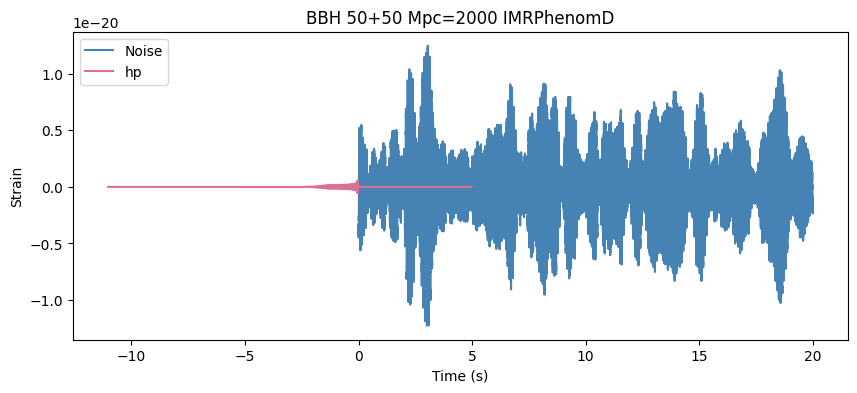

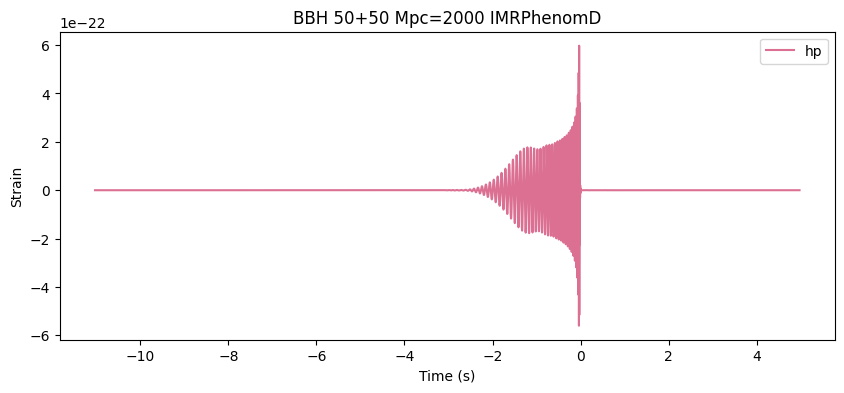

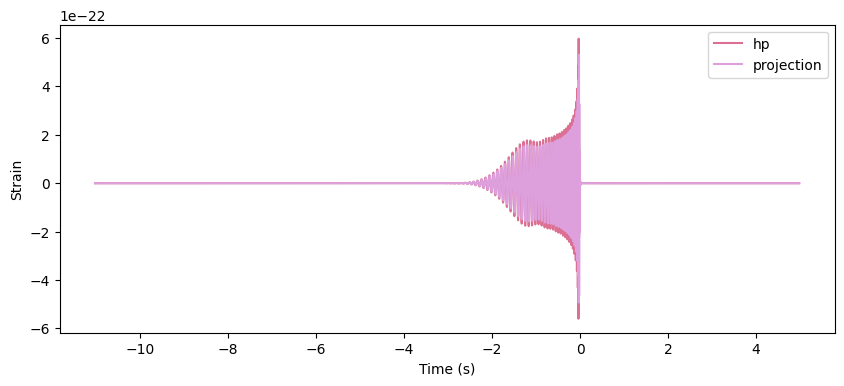

81920
65602


In [75]:

#Defining the variables
m1 = 50
m2 = 50
RA = random.uniform(0, 2*np.pi) #Take a random point in the range to look at the collision from
DEC = random.uniform(-2np.pi, 2*np.pi)
POL = random.uniform(0, 2*np.pi)
detector = Detector("L1")
#Generating the waveform
hp, hc = get_td_waveform(approximant="IMRPhenomD", mass1=m1, mass2=m2, distance=2000, delta_t=1/4096, f_lower = 12)
projection = detector.project_wave(hp, hc, RA, DEC, POL)

#Set the starting time at the same point so the graph would look better
hp.start_time = noise.start_time
hp.start_time = projection.start_time

print(hp.delta_f)

#Plot the noise and the hp/hc to compare
plt.figure(figsize=(10,4))
plt.plot(noise.sample_times, noise, label="Noise", color = "steelblue")
plt.plot(hp.sample_times, hp, label="hp", color = "palevioletred")
#No need to add plt.plot(hc.sample_times, hc, label="hc") to the graph, since hp and hc overlap
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.legend()
plt.title("BBH 50+50 Mpc=2000 IMRPhenomD")
plt.show()

#Since the hp/hc is not very visible when plotted on the same graph as the noise, plotting it again, now separately
plt.figure(figsize=(10,4))
plt.plot(hp.sample_times, hp, label="hp", color = "palevioletred")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.legend()
plt.title("BBH 50+50 Mpc=2000 IMRPhenomD")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(hp.sample_times, hp, label="hp", color = "palevioletred")
plt.plot(projection.sample_times, projection, label="projection", color = "plum")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.legend()
plt.show()

print(len(noise))
print(len(projection))

How does the waveform amplitude compare to the detector noise?
The data is much bigger in amplitude (the wave is plotted with the order of magnitude e-22, and the noise with e-20), therefore it is impossible to observe the wave based off only on the original data.

How does the waveform change because of this projection?
The projection is smaller in amplitude -- since it is projected, the wave is not seen as a whole

**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


0.05


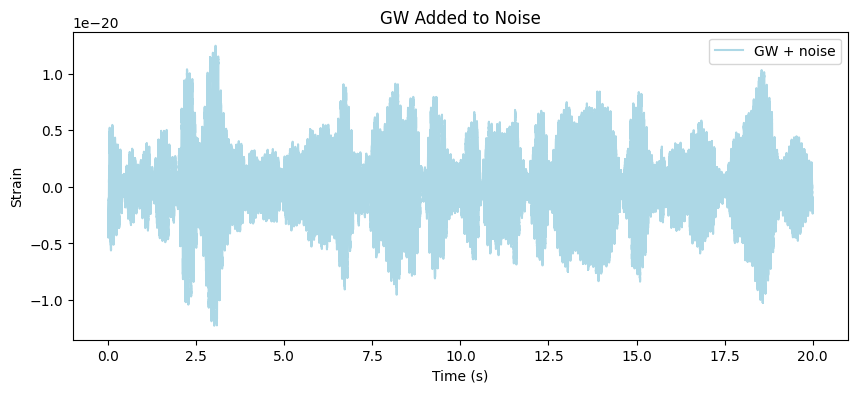

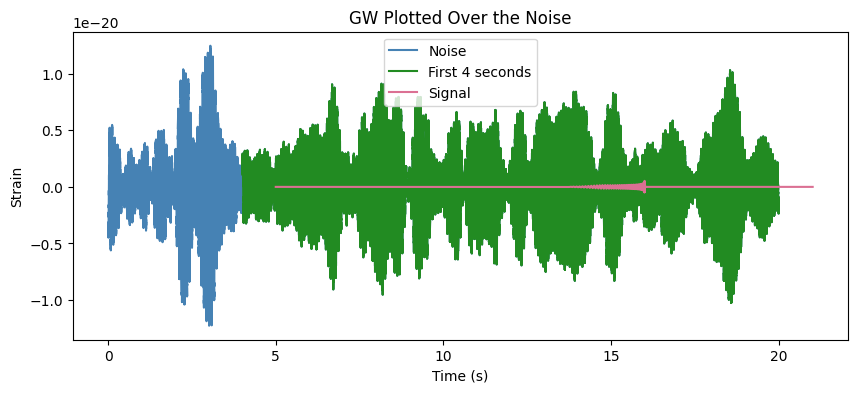

In [77]:
#Setting the starting times for noise and projection
noise.start_time = 0
projection.start_time = 5

#Adding the gravitational wave to the noise
start = int(5/dlt_t)
GW_noisy = noise.copy() #Making a copy, because otherwise my delta_f was getting weird. I assume that, by making a copy, the delta_f was also copied from noise to the GW_noisy
GW_noisy[start : start+len(noise)] += projection[:len(noise) - start]
#Get the first four seconds
start = int(4/dlt_t)
#first four seconds:
ffs = noise[start : start+len(projection[:len(noise)-start])]
#Plot the GW added to the noisy data
plt.figure(figsize=(10,4))
plt.plot(GW_noisy.sample_times, GW_noisy, label="GW + noise", color = "lightblue")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.legend()
plt.title("GW Added to Noise")
plt.show()

#Plot the noise and the projection to compare, now with the projection starting at 5 seconds and the first four seconds
plt.figure(figsize=(10,4))
plt.plot(noise.sample_times, noise, label="Noise", color = "steelblue")
plt.plot(ffs.sample_times, ffs, label="First 4 seconds", color = "forestgreen")
plt.plot(projection.sample_times, projection, label="Signal", color = "palevioletred")
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.legend()
plt.title("GW Plotted Over the Noise")
plt.show()






**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


Delta f: 0.25


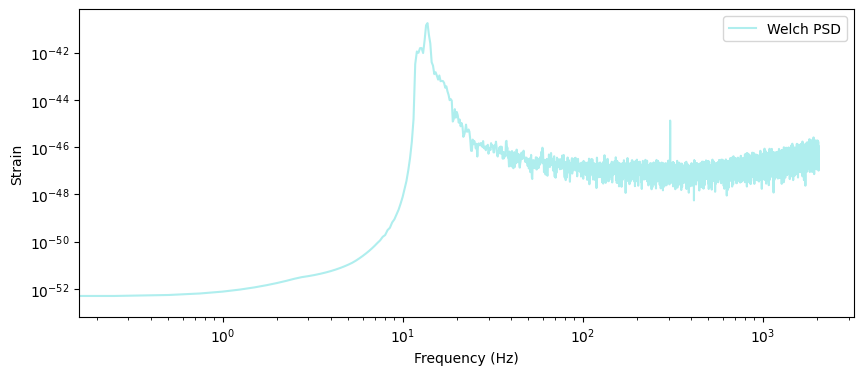

In [44]:
#Making the welch data structure
welch = pycbc.psd.estimate.welch(ffs, 4*4096, 2*4096)

plt.figure(figsize=(10,4))
plt.loglog(welch.sample_frequencies, welch, label="Welch PSD", color = "paleturquoise") #Plotting as loglog since it's psd
plt.xlabel("Frequency (Hz)")
plt.ylabel("Strain")
plt.legend()

#Showing the delta f
print("Delta f:", welch.delta_f)

Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

In [51]:
max_filter_len = 4 * 4096
interp_welch = pycbc.psd.estimate.interpolate(welch, noise.delta_f)
psd = pycbc.psd.estimate.inverse_spectrum_truncation(interp_welch, max_filter_len = max_filter_len, low_frequency_cutoff=12.0)

print("Interpolated and truncated PSD:", psd)

Interpolated and truncated PSD: [3.60780716e-41 1.88013087e-41 1.05892770e-41 ... 6.41932965e-47
 6.34363892e-47 6.32130324e-47]


Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

Text(0, 0.5, 'Strain')

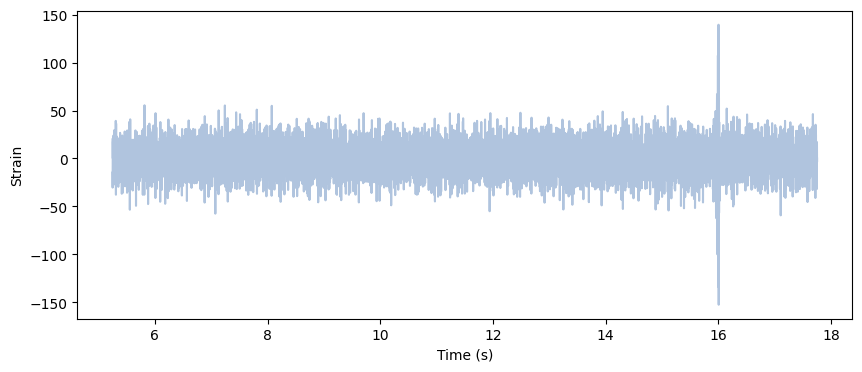

In [94]:


f_GW_noisy = GW_noisy.to_frequencyseries() #Changing the data from time series to frequency series

wh_GW_noisy = f_GW_noisy / np.sqrt(psd) #the equation indicated

wh_GW_noisy = wh_GW_noisy.to_timeseries() #Changing the data from frequency series back to time series
#Now we need to cut the borders of the data:
wh_GW_noisy = wh_GW_noisy[int(5/wh_GW_noisy.delta_t):int(18/wh_GW_noisy.delta_t)]

#Bandpassing the data
wh_l_data = wh_GW_noisy.lowpass_fir(250, 512)
wh_h_data = wh_l_data.highpass_fir(30, 512)

#Plotting the data
plt.figure(figsize=(10,4))
plt.plot(wh_h_data.sample_times, wh_h_data, label="Whitenned Data", color = "lightsteelblue")
plt.xlabel("Time (s)")
plt.ylabel("Strain")

So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

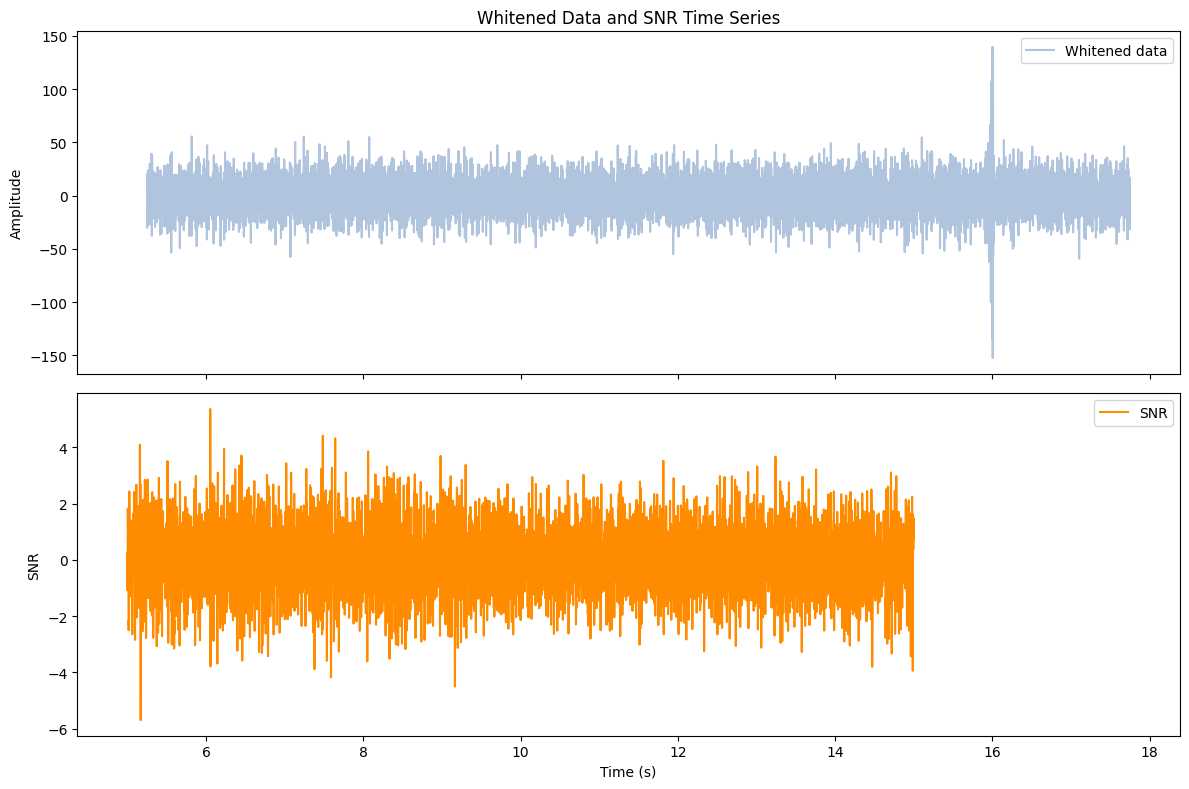

Maximum of |SNR| time series: 6.015790144686066
Peak time = 5.17 s
Yes, a trigger will be generated! :)


In [108]:
#Making a copy just to be safe, I am not ready to go through the suffering with deltas again
template = hp.copy()
#Resizing the template to match the data length
template.resize(len(GW_noisy))
template = template.cyclic_time_shift(5.0) #For some reason, the graph looked cleaner when I did not add this line, with maximum SNR at 26.261754086009535 and peak time pretty much the same

#Computing the matched filter SNR time series
snr = matched_filter(template, GW_noisy, psd=psd, low_frequency_cutoff=20.0)
#Cropping 5s each side
dt = snr.delta_t
crop_left = int(5.0 / dt)
crop_right = int(5.0 / dt)
snr_cropped = snr[crop_left:-crop_right]

#Plotting the whitened data together with SNR
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(wh_h_data.sample_times, wh_h_data, label='Whitened data', color='lightsteelblue')
ax1.set_ylabel('Amplitude')
ax1.legend()
ax1.set_title('Whitened Data and SNR Time Series')

ax2.plot(snr_cropped.sample_times, snr_cropped, label='SNR', color='darkorange')
ax2.set_ylabel('SNR')
ax2.set_xlabel('Time (s)')
ax2.legend()

plt.tight_layout()
plt.show()

#Maximum of the absolute velue of SNR:
max_abs_snr = abs(snr_cropped).max()
print(f'Maximum of |SNR| time series: {max_abs_snr}')
peak_time = float(snr_cropped.sample_times[np.argmax(np.abs(snr_cropped))])
print(f"Peak time = {peak_time:.2f} s")
#Checking if trigger generated with threshold at greater than 5
if max_abs_snr > 5:
    print('Yes, a trigger will be generated! :)')
else:
    print('No trigger. >:()')

Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.